# Nemotron weight-distribution analysis
This notebook loads the weight histograms saved by `weight_distribution.py`, checks their metadata and overflow mass, fits Gaussian, exponential, and polynomial distributions by maximum likelihood, and plots the best fits with R² and equations.
Generate or refresh the artifact by running `weight_distribution.py` before this notebook.

In [1]:
from pathlib import Path
import sys
import torch
from IPython.display import Markdown, display
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "llm_analysis" / "weight_distribution.py").exists():
            return candidate / "llm_analysis"
    raise FileNotFoundError("Could not locate the llm_analysis project root")
PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from histogram import (
    DEFAULT_BULK_MASS,
    fit_histogram_distributions,
    plot_histogram_fits,
)
from weight_distribution import RESULTS_FORMAT_VERSION
RESULTS_PATH = PROJECT_ROOT / "weight_distribution_results.pt"
RESULTS_PATH


PosixPath('/home/bubbles/Documents/lossless_compression/llm_analysis/weight_distribution_results.pt')

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"{RESULTS_PATH} does not exist. Run weight_distribution.py first."
    )

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=True)
if results.get("format_version") != RESULTS_FORMAT_VERSION:
    raise ValueError(
        f"Result format {results.get('format_version')!r} is stale; "
        f"expected {RESULTS_FORMAT_VERSION}. Rerun weight_distribution.py."
    )

histograms = results["histograms"]
edges = results["edges"]
extrema = results["extrema"]
category_names = results["categories"]

metadata = {
    key: results[key]
    for key in ("model_name", "bin_width", "limit")
}
metadata

{'model_name': 'nvidia/Nemotron-H-8B-Base-8K',
 'bin_width': 0.01,
 'limit': 50.0}

In [3]:
if set(histograms) != set(extrema) or set(histograms) != set(category_names):
    raise ValueError("Histogram, extrema, and category labels do not match")
if any(counts.numel() != edges.numel() + 1 for counts in histograms.values()):
    raise ValueError("Histogram counts are incompatible with the saved bin edges")

summary_rows = []
for label, counts in histograms.items():
    minimum, maximum = extrema[label]
    total = int(counts.sum())
    overflow = int(counts[0] + counts[-1])
    summary_rows.append(
        (
            label,
            f"{total:,}",
            f"{minimum.item():.6g}",
            f"{maximum.item():.6g}",
            f"{overflow / total:.3%}",
        )
    )

def show_table(headers, rows):
    header = "| " + " | ".join(headers) + " |"
    divider = "| " + " | ".join("---" for _ in headers) + " |"
    body = ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join((header, divider, *body))))

show_table(
    ("Weight category", "Observations", "Minimum", "Maximum", "Outside fit range"),
    summary_rows,
)

| Weight category | Observations | Minimum | Maximum | Outside fit range |
| --- | --- | --- | --- | --- |
| Embedding weights | 536,870,912 | -0.196289 | 0.167969 | 0.000% |
| FFN input weights | 2,113,929,216 | -0.484375 | 0.632812 | 0.000% |
| FFN output weights | 2,113,929,216 | -1.14062 | 2.28125 | 0.000% |
| Attention query weights | 67,108,864 | -0.237305 | 0.287109 | 0.000% |
| Attention key weights | 16,777,216 | -0.339844 | 0.435547 | 0.000% |
| Attention value weights | 16,777,216 | -0.241211 | 0.231445 | 0.000% |
| Attention output weights | 67,108,864 | -1.26562 | 0.75 | 0.000% |
| Mamba input weights | 1,824,522,240 | -0.613281 | 0.800781 | 0.000% |
| Mamba output weights | 805,306,368 | -0.972656 | 1.07031 | 0.000% |
| Mamba convolution weights | 1,228,800 | -7.96875 | 32.75 | 0.000% |
| LM head weights | 536,870,912 | -0.157227 | 0.200195 | 0.000% |
| Norm weights | 413,696 | -1.74219 | 44.5 | 0.000% |
| Mamba state parameters | 9,216 | -15.1875 | 18.125 | 0.000% |

In [4]:
# Adjust the central-mass/tail split or show every candidate fit as needed.
bulk_mass = DEFAULT_BULK_MASS
show_all_candidates = False
fits = {}
fit_errors = {}
for label, counts in histograms.items():
    try:
        fits[label] = fit_histogram_distributions(
            {label: counts},
            edges,
            bulk_mass=bulk_mass,
        )[label]
    except (ValueError, RuntimeError) as error:
        fits[label] = {}
        fit_errors[label] = str(error)

fit_rows = []
for label, regions in fits.items():
    for region in ("bulk", "tail"):
        candidates = regions.get(region, [])
        if not candidates:
            fit_rows.append(
                (
                    label,
                    region,
                    "-",
                    "not fitted",
                    "-",
                    "-",
                    "-",
                    fit_errors.get(label, "<3 populated bins"),
                )
            )
            continue
        for rank, fit in enumerate(candidates, start=1):
            if rank > 1 and not show_all_candidates:
                continue
            fit_rows.append(
                (
                    label,
                    region,
                    rank,
                    fit.family,
                    f"{fit.log_likelihood:.4g}",
                    f"{fit.log_rmse:.4f}",
                    f"{fit.r_squared:.4f}",
                    fit.parameters,
                )
            )

show_table(
    (
        "Weight category",
        "Region",
        "Rank",
        "Family",
        "Log-likelihood",
        "log-RMSE",
        "R²",
        "Parameters",
    ),
    fit_rows,
)

| Weight category | Region | Rank | Family | Log-likelihood | log-RMSE | R² | Parameters |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Embedding weights | bulk | 1 | polynomial | 3.231e+09 | 7.2510 | -74.6475 | mu=0.005001, scale=7.538e-09, exponent=1 |
| Embedding weights | tail | 1 | gaussian | 5.178e+07 | 1.2559 | 0.9859 | mu=0.005001, sigma=0.01954 |
| FFN input weights | bulk | 1 | polynomial | 6.872e+09 | 2.1325 | -4.7087 | mu=0.005001, scale=7.787e-05, exponent=1 |
| FFN input weights | tail | 1 | gaussian | 1.092e+08 | 1.1439 | 0.9906 | mu=0.005001, sigma=0.02344 |
| FFN output weights | bulk | 1 | polynomial | 8.734e+09 | 4.4581 | -21.0424 | mu=0.005001, scale=6.378e-07, exponent=1 |
| FFN output weights | tail | 1 | gaussian | 8.625e+07 | 1.6480 | 0.9849 | mu=0.005001, sigma=0.02291 |
| Attention query weights | bulk | 1 | polynomial | 2.962e+08 | 6.2191 | -69.2496 | mu=0.005001, scale=1.069e-08, exponent=1 |
| Attention query weights | tail | 1 | gaussian | 6.678e+06 | 0.9096 | 0.9884 | mu=0.005001, sigma=0.02605 |
| Attention key weights | bulk | 1 | polynomial | 5.496e+07 | 3.3999 | -10.3796 | mu=-0.005, scale=3.655e-06, exponent=1 |
| Attention key weights | tail | 1 | gaussian | 9.968e+05 | 0.7768 | 0.9897 | mu=-0.005, sigma=0.03193 |
| Attention value weights | bulk | 1 | polynomial | 2.062e+08 | 20.6408 | -211.0104 | mu=-0.005, scale=7.662e-20, exponent=1 |
| Attention value weights | tail | 1 | gaussian | 1.192e+06 | 0.5306 | 0.9925 | mu=-0.005, sigma=0.03658 |
| Attention output weights | bulk | 1 | polynomial | 3.194e+08 | 5.8002 | -30.8525 | mu=0.005001, scale=4.877e-08, exponent=1 |
| Attention output weights | tail | 1 | gaussian | 3.642e+06 | 3.1810 | 0.9009 | mu=0.005001, sigma=0.02697 |
| Mamba input weights | bulk | 1 | polynomial | 5.913e+09 | 2.2658 | -5.3732 | mu=0.005001, scale=5.766e-05, exponent=1 |
| Mamba input weights | tail | 1 | gaussian | 9.743e+07 | 1.1347 | 0.9909 | mu=0.005001, sigma=0.02518 |
| Mamba output weights | bulk | 1 | polynomial | 2.783e+09 | 2.6566 | -5.9265 | mu=0.005001, scale=2.626e-05, exponent=1 |
| Mamba output weights | tail | 1 | gaussian | 2.701e+07 | 2.1666 | 0.9667 | mu=0.005001, sigma=0.02479 |
| Mamba convolution weights | bulk | 1 | polynomial | 2.363e+07 | 33.8107 | -185.8913 | mu=-0.005, scale=1.235e-29, exponent=1 |
| Mamba convolution weights | tail | 1 | polynomial | 2215 | 0.6082 | 0.9837 | mu=-0.005, scale=1.658e-10, exponent=2.254 |
| LM head weights | bulk | 1 | polynomial | 4.631e+09 | 11.2275 | -105.8806 | mu=-0.005, scale=1.192e-11, exponent=1 |
| LM head weights | tail | 1 | gaussian | 2.306e+07 | 1.3791 | 0.9826 | mu=-0.005, sigma=0.01917 |
| Norm weights | bulk | 1 | polynomial | -6.713e+05 | 0.9671 | 0.2418 | mu=1.105, scale=1.885, exponent=3.202 |
| Norm weights | tail | 1 | polynomial | -5.057e+04 | 2.2398 | 0.1613 | mu=1.105, scale=4.208, exponent=6.314 |
| Mamba state parameters | bulk | 1 | polynomial | -1.947e+04 | 0.8181 | 0.3795 | mu=-0.005, scale=0.3334, exponent=1 |
| Mamba state parameters | tail | 1 | exponential | -1059 | 2.1797 | -6.8499 | mu=-0.005, scale=1.848 |

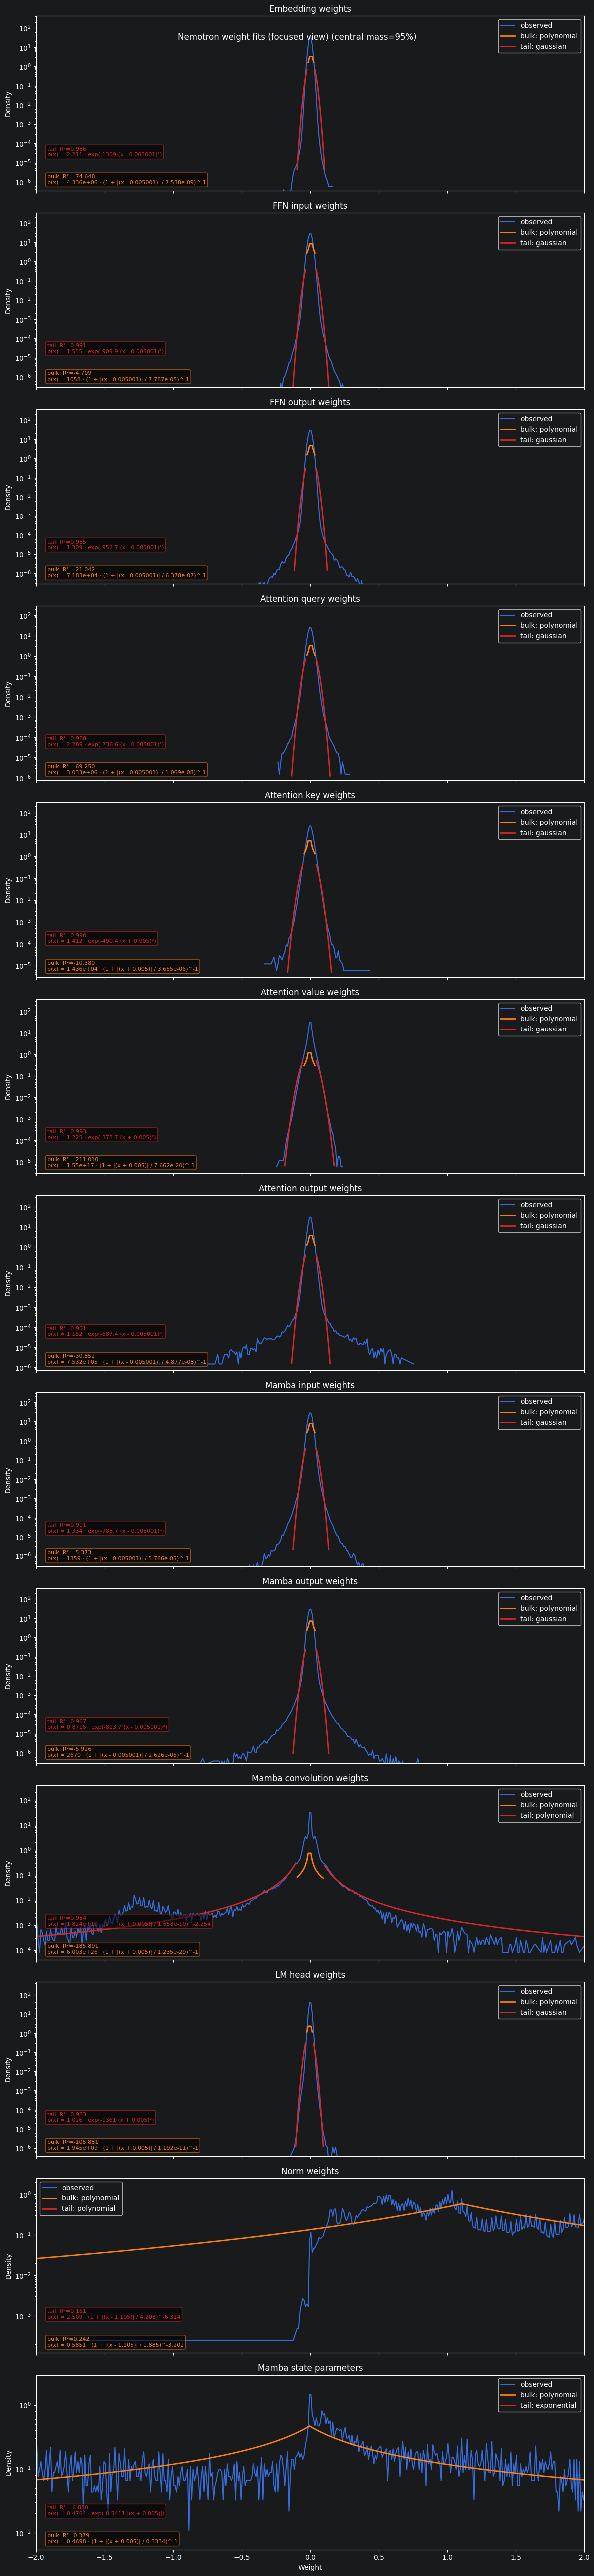

In [5]:
# Projection weights are concentrated near zero; the extrema table above retains outliers.
plot_histogram_fits(
    histograms,
    edges,
    fits,
    bulk_mass=bulk_mass,
    title="Nemotron weight fits (focused view)",
    x_label="Weight",
    x_limits=(-2.0, 2.0),
)